In [68]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, Dropout
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [21]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [35]:
nsamples, nx, ny = x_train.shape
x_train_d2 = x_train.reshape((nsamples, nx * ny))
x_train_normed = StandardScaler().fit_transform(x_train_d2)

nsamples, nx, ny = x_test.shape
x_test_d2 = x_test.reshape((nsamples, nx * ny))
x_test_normed = StandardScaler().fit_transform(x_test_d2)

In [51]:
y_train_ohe = pd.get_dummies(y_train).as_matrix()
y_test_ohe = pd.get_dummies(y_test).as_matrix()

Baseline model

In [60]:
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
print(nn_model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 32)                25120     
_________________________________________________________________
dense_13 (Dense)             (None, 32)                1056      
_________________________________________________________________
output (Dense)               (None, 10)                330       
Total params: 26,506
Trainable params: 26,506
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.7474 - acc: 0.7875 - val_loss: 0.3449 - val_acc: 0.9005
Epoch 2/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.3018 - acc: 0.9123 - val_loss: 0.2652 - val_acc: 0.9236
Epoch 3/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2428 - acc: 0.9281 - val_loss: 0.2324 - val_acc: 0.9327
Epoch 4/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2112 - acc: 0.9377 - val_loss: 0.2118 - val_acc: 0.9371
Epoch 5/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1897 - acc: 0.9438 - val_loss: 0.1977 - val_acc: 0.9414
Epoch 6/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1737 - acc: 0.9483 - val_loss: 0.1879 - val_acc: 0.9451
Epoch 7/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1607 - acc: 0.9523 - val_loss: 0.1789 - val_acc

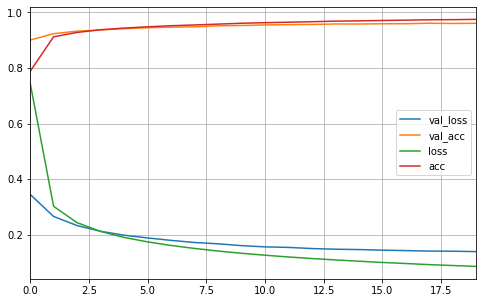

CPU times: user 1min 4s, sys: 8.84 s, total: 1min 13s
Wall time: 45.8 s


In [54]:
%%time
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [44]:
def save_keras_model(model, history, file_name):
    model_json = model.to_json()
    with open("./models/{}.json".format(file_name), 'w') as json_file:
        json_file.write(model_json)
    model.save_weights("./models/{}.h5".format(file_name))
    with open('./models/{}.history'.format(file_name), 'wb') as file_history:
        pickle.dump(history.history, file_history)
    print("model saved")
save_keras_model(nn_model, history, 'base_model')

model saved


Model with 64 neurons

In [58]:
model_sequences = [
    keras.layers.Dense(units=64, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=64, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_64 = keras.models.Sequential(model_sequences)
print(nn_model_64.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_10 (Dense)             (None, 64)                50240     
_________________________________________________________________
dense_11 (Dense)             (None, 64)                4160      
_________________________________________________________________
output (Dense)               (None, 10)                650       
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 57us/step - loss: 0.7306 - acc: 0.7913 - val_loss: 0.3328 - val_acc: 0.9039
Epoch 2/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.2856 - acc: 0.9179 - val_loss: 0.2483 - val_acc: 0.9271
Epoch 3/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.2224 - acc: 0.9351 - val_loss: 0.2116 - val_acc: 0.9382
Epoch 4/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.1888 - acc: 0.9440 - val_loss: 0.1919 - val_acc: 0.9436
Epoch 5/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.1660 - acc: 0.9503 - val_loss: 0.1778 - val_acc: 0.9487
Epoch 6/20
60000/60000 [==============================] - 2s 41us/step - loss: 0.1493 - acc: 0.9564 - val_loss: 0.1669 - val_acc: 0.9523
Epoch 7/20
60000/60000 [==============================] - 2s 41us/step - loss: 0.1361 - acc: 0.9600 - val_loss: 0.1587 - val_acc

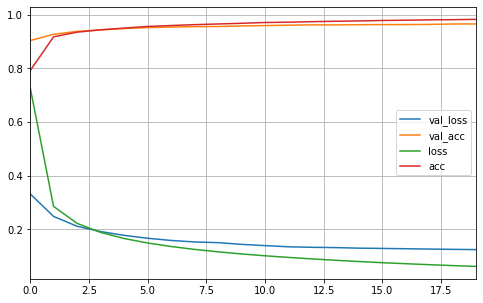

CPU times: user 1min 16s, sys: 10.4 s, total: 1min 26s
Wall time: 51 s


In [59]:
%%time
nn_model_64.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_64.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_64, history, 'model_64_n')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Models with different learning rates

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 5s 86us/step - loss: 0.3385 - acc: 0.9012 - val_loss: 0.2014 - val_acc: 0.9422
Epoch 2/20
60000/60000 [==============================] - 3s 44us/step - loss: 0.1672 - acc: 0.9522 - val_loss: 0.1900 - val_acc: 0.9472
Epoch 3/20
60000/60000 [==============================] - 3s 48us/step - loss: 0.1295 - acc: 0.9628 - val_loss: 0.1625 - val_acc: 0.9560
Epoch 4/20
60000/60000 [==============================] - 3s 55us/step - loss: 0.1078 - acc: 0.9690 - val_loss: 0.1507 - val_acc: 0.9592
Epoch 5/20
60000/60000 [==============================] - 3s 56us/step - loss: 0.0926 - acc: 0.9727 - val_loss: 0.1570 - val_acc: 0.9608
Epoch 6/20
60000/60000 [==============================] - 3s 55us/step - loss: 0.0830 - acc: 0.9766 - val_loss: 0.1498 - val_acc: 0.9602
Epoch 7/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.0733 - acc: 0.9790 - val_loss: 0.1583 - val_acc

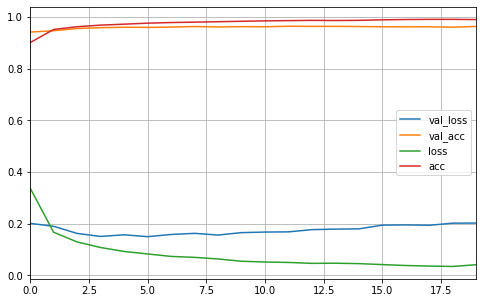

CPU times: user 1min 21s, sys: 10.5 s, total: 1min 32s
Wall time: 1min 1s


In [94]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_lr = keras.models.Sequential(model_sequences)
sgd = SGD(lr=0.01, decay=0.000001, momentum=0.9)
nn_model_lr.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_lr.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_lr, history, 'model_lr')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with batch size 32

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 4s 69us/step - loss: 0.5668 - acc: 0.8365 - val_loss: 0.2792 - val_acc: 0.9148
Epoch 2/20
60000/60000 [==============================] - 4s 61us/step - loss: 0.2404 - acc: 0.9287 - val_loss: 0.2181 - val_acc: 0.9351
Epoch 3/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1919 - acc: 0.9427 - val_loss: 0.1942 - val_acc: 0.9410
Epoch 4/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1651 - acc: 0.9514 - val_loss: 0.1799 - val_acc: 0.9466
Epoch 5/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1465 - acc: 0.9572 - val_loss: 0.1711 - val_acc: 0.9500
Epoch 6/20
60000/60000 [==============================] - 4s 60us/step - loss: 0.1330 - acc: 0.9608 - val_loss: 0.1595 - val_acc: 0.9534
Epoch 7/20
60000/60000 [==============================] - 4s 61us/step - loss: 0.1216 - acc: 0.9639 - val_loss: 0.1558 - val_acc

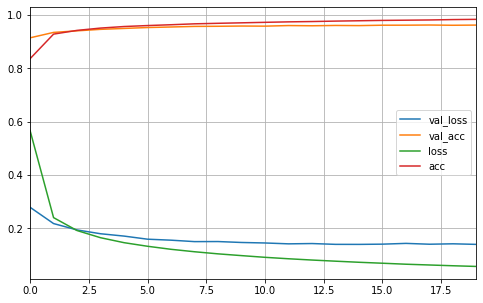

CPU times: user 1min 47s, sys: 16.6 s, total: 2min 4s
Wall time: 1min 15s


In [64]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_bs_32 = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=32, verbose=1)
# save_keras_model(nn_model, history, 'model_64_n')
pd.DataFrame(history_bs_32.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with batch size 128

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 56us/step - loss: 1.0841 - acc: 0.6896 - val_loss: 0.5117 - val_acc: 0.8577
Epoch 2/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.4331 - acc: 0.8779 - val_loss: 0.3595 - val_acc: 0.8952
Epoch 3/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.3334 - acc: 0.9035 - val_loss: 0.3063 - val_acc: 0.9091
Epoch 4/20
60000/60000 [==============================] - 2s 30us/step - loss: 0.2860 - acc: 0.9172 - val_loss: 0.2741 - val_acc: 0.9196
Epoch 5/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2560 - acc: 0.9252 - val_loss: 0.2529 - val_acc: 0.9266
Epoch 6/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.2344 - acc: 0.9315 - val_loss: 0.2376 - val_acc: 0.9301
Epoch 7/20
60000/60000 [==============================] - 2s 33us/step - loss: 0.2174 - acc: 0.9368 - val_loss: 0.2249 - val_acc

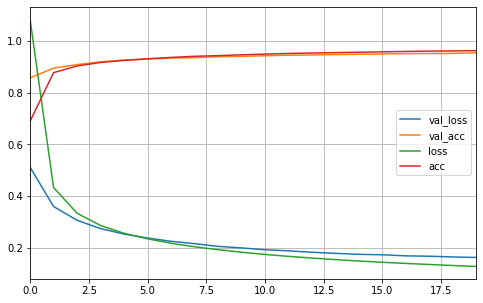

CPU times: user 51 s, sys: 7.48 s, total: 58.5 s
Wall time: 41 s


In [73]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_bs_128 = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=128, verbose=1)
# save_keras_model(nn_model, history, 'model_64_n')
pd.DataFrame(history_bs_128.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with another hidden layer

In [95]:
print(nn_model_3_layers.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_22 (Dense)             (None, 32)                25120     
_________________________________________________________________
dense_23 (Dense)             (None, 32)                1056      
_________________________________________________________________
dense_24 (Dense)             (None, 32)                1056      
_________________________________________________________________
output (Dense)               (None, 10)                330       
Total params: 27,562
Trainable params: 27,562
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 5s 82us/step - loss: 0.9074 - acc: 0.7355 - val_loss: 0.3693 - val_acc: 0.8947
Epoch 2/20
60000/60000 [==============================] - 3s 48us/step - loss: 0.3178 - acc: 0.9079 - val_loss: 0.2686 - val_acc: 0.9230
Epoch 3/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.2468 - acc: 0.9283 - val_loss: 0.2346 - val_acc: 0.9319
Epoch 4/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.2115 - acc: 0.9385 - val_loss: 0.2140 - val_acc: 0.9383
Epoch 5/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.1875 - acc: 0.9452 - val_loss: 0.1980 - val_acc: 0.9435
Epoch 6/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.1705 - acc: 0.9495 - val_loss: 0.1888 - val_acc: 0.9450
Epoch 7/20
60000/60000 [==============================] - 3s 47us/step - loss: 0.1564 - acc: 0.9541 - val_loss: 0.1802 - val_acc

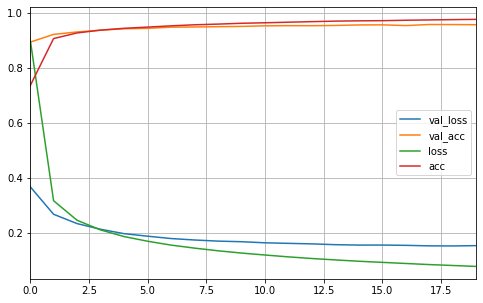

CPU times: user 1min 24s, sys: 11.3 s, total: 1min 35s
Wall time: 1min 1s


In [96]:
%%time
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_3_layers = keras.models.Sequential(model_sequences)
nn_model_3_layers.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_3_layers.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_3_layers, history, 'model_3_layers')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Model with 128, 128, 10 and dropout

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 8s 127us/step - loss: 0.8418 - acc: 0.7389 - val_loss: 0.3198 - val_acc: 0.9068
Epoch 2/20
60000/60000 [==============================] - 4s 68us/step - loss: 0.4371 - acc: 0.8692 - val_loss: 0.2565 - val_acc: 0.9229
Epoch 3/20
60000/60000 [==============================] - 5s 86us/step - loss: 0.3613 - acc: 0.8921 - val_loss: 0.2278 - val_acc: 0.9311
Epoch 4/20
60000/60000 [==============================] - 5s 82us/step - loss: 0.3262 - acc: 0.9026 - val_loss: 0.2060 - val_acc: 0.9400
Epoch 5/20
60000/60000 [==============================] - 4s 74us/step - loss: 0.2957 - acc: 0.9108 - val_loss: 0.1913 - val_acc: 0.9440
Epoch 6/20
60000/60000 [==============================] - 5s 91us/step - loss: 0.2753 - acc: 0.9173 - val_loss: 0.1808 - val_acc: 0.9469
Epoch 7/20
60000/60000 [==============================] - 5s 87us/step - loss: 0.2565 - acc: 0.9215 - val_loss: 0.1712 - val_ac

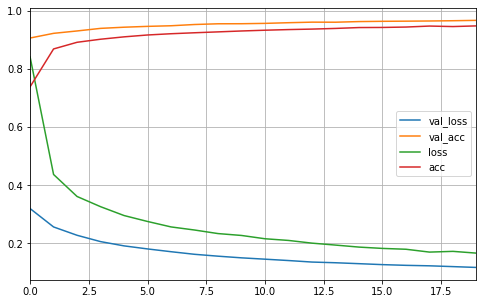

CPU times: user 2min 45s, sys: 16.9 s, total: 3min 2s
Wall time: 1min 45s


In [100]:
%%time
model_sequences = [
    keras.layers.Dropout(rate=0.2, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dropout(rate=0.2, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=128, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dropout(rate=0.2, input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_dropout = keras.models.Sequential(model_sequences)
nn_model_dropout.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_dropout.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
save_keras_model(nn_model_dropout, history, 'model_128_dropout')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 27s 443us/step - loss: 0.2419 - acc: 0.9325 - val_loss: 0.1450 - val_acc: 0.9609
Epoch 2/20
60000/60000 [==============================] - 23s 386us/step - loss: 0.1035 - acc: 0.9713 - val_loss: 0.1174 - val_acc: 0.9695
Epoch 3/20
60000/60000 [==============================] - 24s 392us/step - loss: 0.0669 - acc: 0.9815 - val_loss: 0.1071 - val_acc: 0.9726
Epoch 4/20
60000/60000 [==============================] - 24s 400us/step - loss: 0.0505 - acc: 0.9869 - val_loss: 0.1089 - val_acc: 0.9737
Epoch 5/20
60000/60000 [==============================] - 24s 408us/step - loss: 0.0386 - acc: 0.9904 - val_loss: 0.1093 - val_acc: 0.9754
Epoch 6/20
60000/60000 [==============================] - 25s 417us/step - loss: 0.0371 - acc: 0.9920 - val_loss: 0.1148 - val_acc: 0.9721
Epoch 7/20
60000/60000 [==============================] - 25s 418us/step - loss: 0.0313 - acc: 0.9936 - val_loss: 0.

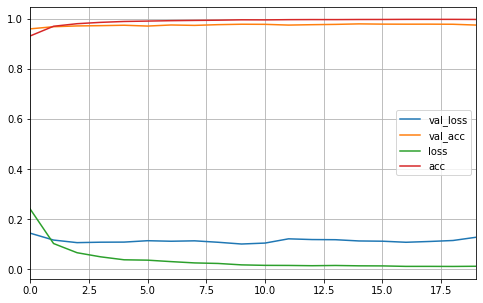

CPU times: user 19min 3s, sys: 2min 46s, total: 21min 50s
Wall time: 8min 26s


In [116]:
%%time
act_alpha = 0.01
model_sequences = [
    keras.layers.Dropout(rate=0.03, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=700,
                       activation='relu',
                       input_shape=x_train_normed.shape[1:]),
    #keras.layers.LeakyReLU(alpha=act_alpha),
    keras.layers.Dropout(rate=0.05, input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=700,
                       activation='relu',
                       input_shape=x_train_normed.shape[1:]),
    #keras.layers.LeakyReLU(alpha=act_alpha),
    #keras.layers.Dropout(rate=0.05, input_shape=x_train_normed.shape[1:]),
#     keras.layers.Dense(units=128,
#                        activation='relu',
#                        input_shape=x_train_normed.shape[1:]),
    #keras.layers.LeakyReLU(alpha=act_alpha),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_dropout = keras.models.Sequential(model_sequences)
sgd = SGD(lr=0.01, decay=0.000001, momentum=0.9)
nn_model_dropout.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_dropout.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=32, verbose=1)
save_keras_model(nn_model_dropout, history, 'model_best')
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [117]:
print(nn_model_dropout.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dropout_59 (Dropout)         (None, 784)               0         
_________________________________________________________________
dense_125 (Dense)            (None, 700)               549500    
_________________________________________________________________
dropout_60 (Dropout)         (None, 700)               0         
_________________________________________________________________
dense_126 (Dense)            (None, 700)               490700    
_________________________________________________________________
output (Dense)               (None, 10)                7010      
Total params: 1,047,210
Trainable params: 1,047,210
Non-trainable params: 0
_________________________________________________________________
None
